In [7]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os
import shutil

# So the Jupyter kernel finds LaTeX when started from Cursor/VS Code
if not shutil.which('pdflatex'):
    os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ.get('PATH', '')

# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels
with open("params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

In [8]:
import os

# Inject TeX into PATH for this Python process
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

import shutil
print("Latex seen by Python:", shutil.which("latex"))

#import matplotlib.pyplot as plt
#plt.rcParams["text.usetex"] = True

Latex seen by Python: /Library/TeX/texbin/latex


In [9]:
# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette

plt.ioff()  # prevent post-execute redraws that can trigger LaTeX errors in callbacks

# Use matplotlib's built-in text (no LaTeX required)
from matplotlib import rc
rc('text', usetex=False)
rc('font', **{'family': 'serif', 'serif': ['DejaVu Serif']})


In [10]:
chain = np.load('../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_step_4bins_fixnuisance.npz', allow_pickle=True)


In [11]:
#chain, derived, weights, logl, param_names,derived_names,logz,chain_time, chain_time_hms, fiducial
fiducials  = chain['fiducial'].flat[0]
fiducials['h'] = fiducials['H0']/100.
fiducials['logAs'] = np.log(1e10*fiducials['As'])
fiducials['omch2'] = fiducials['Omega_cdm0']*fiducials['h']*fiducials['h']
fiducials['ombh2'] = fiducials['Omega_b0']*fiducials['h']*fiducials['h']
fiducials['sigma8_0'] = 0.8120011480183122
fiducials['Omega_m'] = (fiducials['omch2']+fiducials['ombh2']+fiducials['mnu']/93.14)/fiducials['h']**2
fiducials['S8'] = fiducials['sigma8_0']*np.sqrt(fiducials['Omega_m']/0.3)


In [ ]:
# List of MCMC chain files to compare
file_paths = ['../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_step_4bins_fixnuisance.npz',
             '../sampling/chains/chain_checkpoint_3x2pt_DR1_area_1589_realistic_new_covmat_TR1v1.1_binned_wz_step_4bins_fixnuisance_compressedCMB.npz',

 ]  


n_samples = len(file_paths)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = file_paths[i]  
    
    # Load numerical data from chain file
    chain_npz = np.load(file_path, allow_pickle=True)
        
    
    # Store chain data and parameter names
    chains_info[i] = {}
    chains_info[i]['chain'] = np.vstack([chain_npz['chain'].flat[0][par] for par in chain_npz['param_names']]).T
    chains_info[i]['chain'] = np.hstack((chains_info[i]['chain'], chain_npz['derived'].flat[0]['sigma8_0'][:, np.newaxis]))
    print(chains_info[i]['chain'].shape)
    chains_info[i]['weights'] = chain_npz['weights']
    chains_info[i]['logl'] = chain_npz['logl']
    chains_info[i]['pars'] = np.hstack((chain_npz['param_names'], chain['derived_names']))
    chains_info[i]['fiducial'] = chain_npz['fiducial'].flat[0]
    if 'w_i' in chains_info[i]['fiducial']:
        for j in range(len(chains_info[i]['fiducial']['w_i'])):
            chains_info[i]['fiducial']['w'+str(j+1)] = chains_info[i]['fiducial']['w_i'][j]

(15128, 11)
(16368, 11)


In [14]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================

samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    samples.append(
        getdist.MCSamples(
            # Sample data (excluding log-likelihood and weight columns)
            samples = chains_info[i]['chain'],
            # Parameter names
            names = [i for i in chains_info[i]['pars']],
            # Sample weights (exponential of log-likelihood)
            weights=np.exp(chains_info[i]['weights']),
            # LaTeX labels for parameters (from params_dic)
            labels = [params_dic[p] for p in chains_info[i]['pars']],
            # Smoothing settings for 1D and 2D distributions
            #settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
            # Parameter ranges for plotting
            #ranges = Ranges
        ) 
    )
    mnu = chains_info[i]['fiducial']['mnu']
    if 'H0' in chains_info[i]['pars']:
        p = samples[i].getParams() 
        samples[i].addDerived(p.H0/100., 'h','h')
        p = samples[i].getParams() 
        samples[i].addDerived((p.omch2+p.ombh2+mnu/93.14)/p.h**2, 'Omega_m','\Omega_{\\rm m}')
        p = samples[i].getParams() 
        samples[i].addDerived(p.sigma8_0*np.sqrt(p.Omega_m/0.3), 'S8', 'S_8')


Removed no burn in
Removed no burn in


<>:29: SyntaxWarning: invalid escape sequence '\O'
<>:29: SyntaxWarning: invalid escape sequence '\O'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_65842/2413910747.py:29: SyntaxWarning: invalid escape sequence '\O'
  samples[i].addDerived((p.omch2+p.ombh2+mnu/93.14)/p.h**2, 'Omega_m','\Omega_{\\rm m}')


In [15]:
# Create GetDist subplot plotter
g = getdist.plots.getSubplotPlotter(subplot_size=1.3)

# Configure plot appearance settings
plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=22      # Legend text size
g.settings.axes_fontsize=18        # Axis tick labels size  
g.settings.axes_labelsize=20       # Axis labels size
g.settings.linewidth=4             # Contour line width
g.settings.figure_legend_frame = False  # Remove legend frame


In [16]:
chains_info[0]['pars']

array(['logAs', 'ns', 'omch2', 'ombh2', 'H0', 'w1', 'w2', 'w3', 'w4',
       'w5', 'sigma8_0'], dtype='<U8')

In [21]:
ModelPars = ['w1', 'w2', 'w3', 'w4']
# Legend labels for each chain (LaTeX formatting supported)
legend_labels = [
r'$(\omega_c, \omega_b)_{\rm CMB}$',
r'$(\omega_c, \omega_b, \theta_*)_{\rm CMB}$',
]

<>:50: SyntaxWarning: invalid escape sequence '\e'
<>:50: SyntaxWarning: invalid escape sequence '\e'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_65842/2539048988.py:50: SyntaxWarning: invalid escape sequence '\e'
  annotation_text = '3x2pt, TR1 $n(z)$,\n DR1 covariance,\n DESI CPL fiducial,\n $\ell_{\\rm max}=1500, 750$'


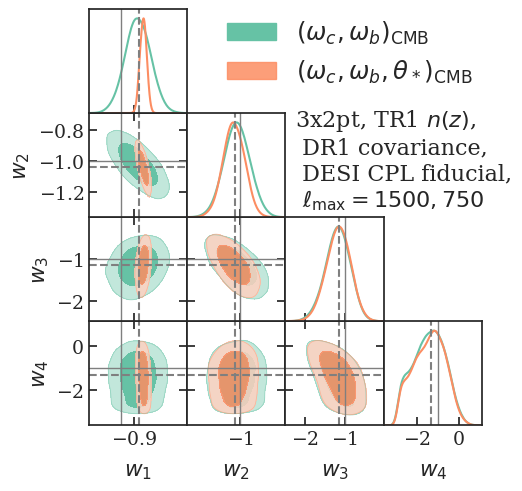

In [26]:
# =============================================================================
# CREATE TRIANGLE PLOT
# =============================================================================

# Generate the main triangle (corner) plot
g.triangle_plot(
    samples,                          # List of MCSamples objects
    ModelPars,                        # Parameters to include in plot
    legend_labels = legend_labels,    # Labels for legend
    legend_loc = 'upper right',       # Legend position
    # Filled contour styling for each sample
    contour_args = [
        {'filled':True, 'color': colors[0]}, 
        {'filled':True, 'color': colors[1], 'ls': '-'}, 
        {'filled':True, 'color': colors[2], 'ls': '-'},
        {'filled':True, 'color': colors[3], 'ls': '-'},  
        {'filled':True, 'color': colors[4], 'ls': '-'},  
        {'filled':True, 'color': colors[5], 'ls': '-'}
    ], 
    # 1D marginalized distribution styling
    line_args=[
        {'color': colors[0], 'ls': '-'}, 
        {'color': colors[1], 'ls': '-'}, 
        {'color': colors[2], 'ls': '-'}, 
        {'color': colors[3], 'ls': '-'}, 
        {'color': colors[4], 'ls': '-'}, 
        {'color': colors[5], 'ls': '-'}
    ]
)

xx = np.linspace(-2., 0., 100)
fiducials = {'w1':-0.86217391,  'w2':-1.03666667,  'w3':-1.14513514,  'w4':-1.32333333, 'w5': -1.60844344}
if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            
            # Add horizontal line for fiducial value of y-parameter (for 2D plots)
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]], lw=1.5, color='tab:gray', linestyle='--')
                ax.axhline(-1., lw=1., color='tab:gray', linestyle='-')
            
            # Add vertical line for fiducial value of x-parameter
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]], lw=1.5, color='tab:gray', linestyle='--')
                ax.axvline(-1., lw=1., color='tab:gray', linestyle='-')

# Position for annotation (subplot index)
num = 1
annotation_text = '3x2pt, TR1 $n(z)$,\n DR1 covariance,\n DESI CPL fiducial,\n $\ell_{\\rm max}=1500, 750$'
# Add text annotation to a specific subplot
ax = g.subplots[num, num]
ax.annotate(annotation_text, (1.1, 0.1), xycoords='axes fraction', 
           clip_on=False, fontsize=16) 
plt.show()